# IMPORTS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve
from scipy.stats import randint, uniform
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [2]:
df= pd.read_csv("../Dataset/WBCD.csv")

In [3]:
df.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [4]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [5]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")
print("-"*100)
print(f"Null Values: {df.isnull().values.any()}\nColumns with Null Values: {df.columns[df.isnull().any()].to_list()}")

# drop coulmns with null values
df= df.drop(columns=['id', 'Unnamed: 32'], axis= 1)
print("-"*100)

Rows: 569
Columns: 33
----------------------------------------------------------------------------------------------------
Null Values: True
Columns with Null Values: ['Unnamed: 32']
----------------------------------------------------------------------------------------------------


In [6]:
target= df['diagnosis'].map({'M': 1, 'B': 0}) # M- malignant, B-Benign
df['diagnosis']= target

[]

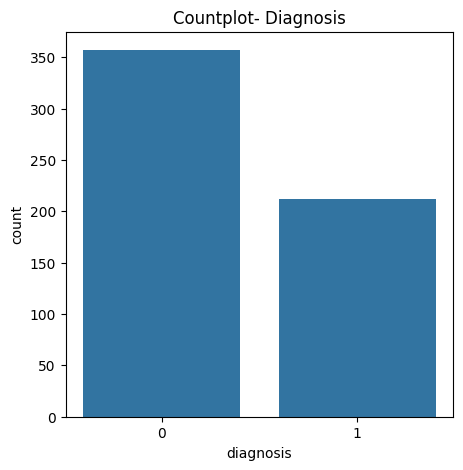

In [7]:
plt.figure(figsize=(5, 5))
sns.countplot(data= df, x= 'diagnosis')
plt.title('Countplot- Diagnosis')
plt.plot()

# CLUSETERMAP - SHOWS HEIRARCHIAL CLUSTERING

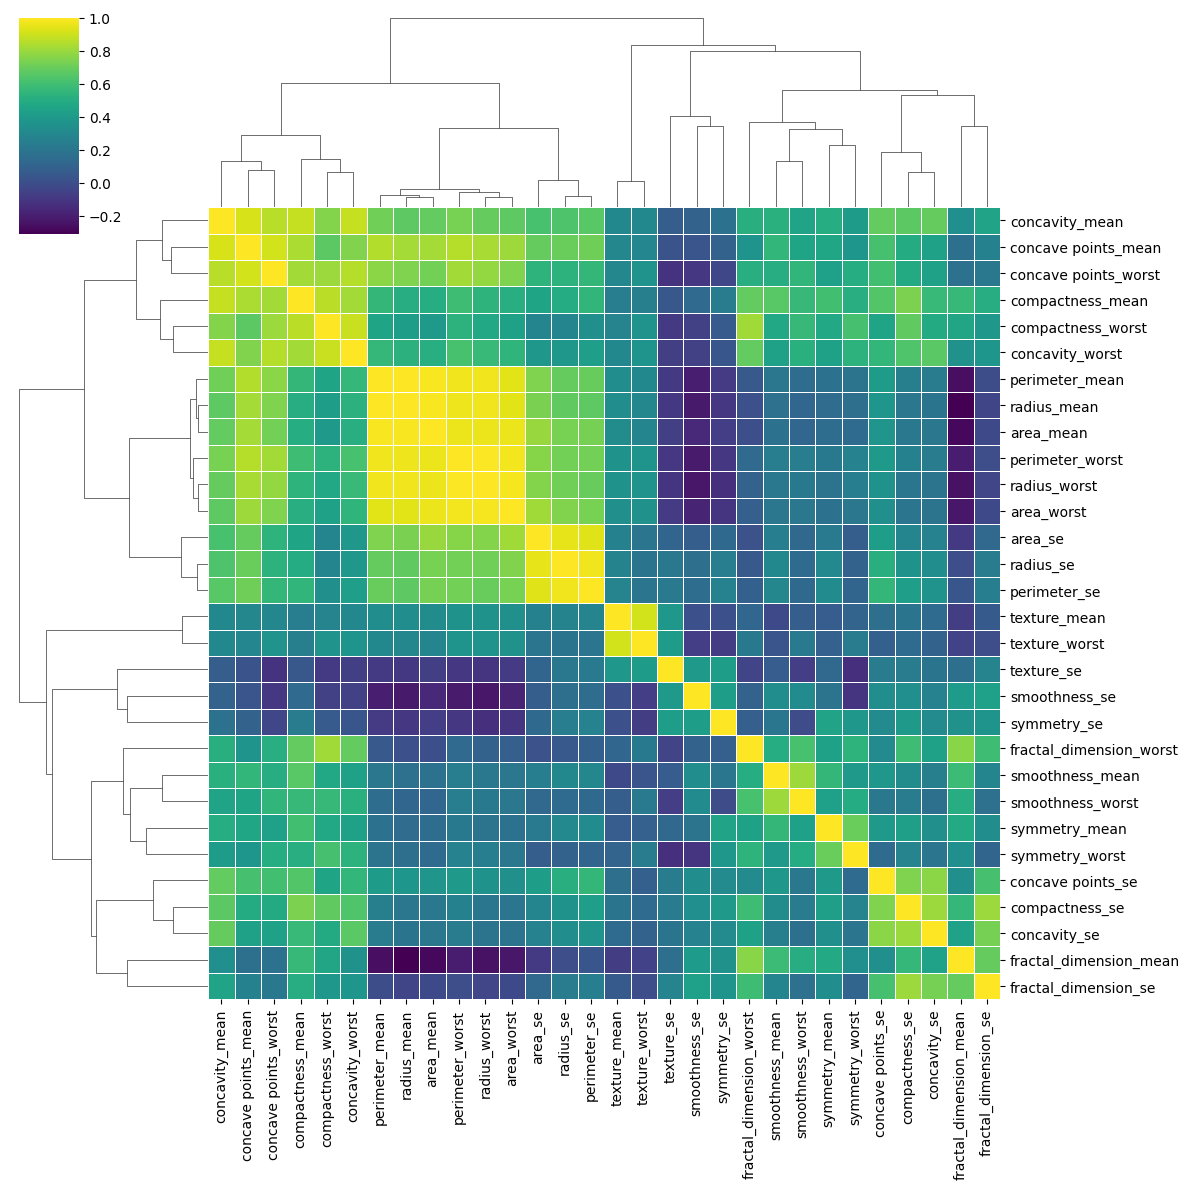

In [8]:
feature_corr= df.drop(columns= ['diagnosis']).corr()

cluster_map= sns.clustermap(feature_corr, annot= False, cmap= 'viridis', figsize= (12, 12), linewidth= .5)
plt.show()

Clustermap shows the redundant features. How?... The dataset has many "cousin" features, e.g. radius, perimeter, area. Using heirarchial clustering, we move similar features next to each other. The bright blocks represent the group of features that are highly redundant or what we call as multicollinear.

# TARGET-ONLY HEATMAP

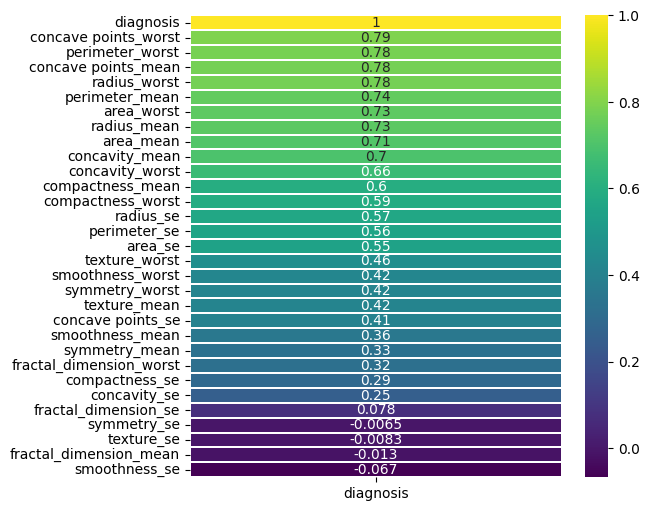

In [9]:
target_corr= df.corr()['diagnosis'].sort_values(ascending=False).to_frame()

plt.figure(figsize= (6, 6))
sns.heatmap(target_corr, annot= True, cmap= 'viridis', linewidths= 0.2)
plt.show()

Target-only heatmap ranks our features, and focuses purely on how well they predict the target i.e. diagnosis.
Based on the results of the target-only heatmap and clustermap we can drop features that are redundant and of no use.

In [10]:
# dropping features with weak relation to the target
low_corr_target = ['fractal_dimension_se','symmetry_se','texture_se',
            'fractal_dimension_mean','smoothness_se']
df = df.drop(columns=low_corr_target)

In [11]:
threshold= 0.9
corr_matrix= df.corr().abs() # absolute correlation matrix

to_drop= set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold: # type: ignore | check if pair is highly correlated
            col_i= corr_matrix.columns[i]
            col_j= corr_matrix.columns[j]

            if abs(df[col_i].corr(df['diagnosis'])) > abs(df[col_j].corr(df['diagnosis'])): # drop feature with low correlation to the target
                to_drop.add(col_j)
            else:
                to_drop.add(col_i)

df_reduced= df.drop(columns= list(to_drop))



In [12]:
print(len(df_reduced.columns.tolist()))
df_reduced.head()

16


,diagnosis,smoothness_mean,compactness_mean,symmetry_mean,radius_se,compactness_se,concavity_se,concave points_se,texture_worst,perimeter_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,0.11840,0.27760,0.2419,1.0950,0.04904,0.05373,0.01587,17.33,184.60,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,0.08474,0.07864,0.1812,0.5435,0.01308,0.01860,0.01340,23.41,158.80,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,0.10960,0.15990,0.2069,0.7456,0.04006,0.03832,0.02058,25.53,152.50,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,0.14250,0.28390,0.2597,0.4956,0.07458,0.05661,0.01867,26.50,98.87,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,0.10030,0.13280,0.1809,0.7572,0.02461,0.05688,0.01885,16.67,152.20,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Description Table

In [13]:
df_reduced.describe()

,diagnosis,smoothness_mean,compactness_mean,symmetry_mean,radius_se,compactness_se,concavity_se,concave points_se,texture_worst,perimeter_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,0.096360,0.104341,0.181162,0.405172,0.025478,0.031894,0.011796,25.677223,107.261213,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,0.014064,0.052813,0.027414,0.277313,0.017908,0.030186,0.006170,6.146258,33.602542,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,0.052630,0.019380,0.106000,0.111500,0.002252,0.000000,0.000000,12.020000,50.410000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,0.086370,0.064920,0.161900,0.232400,0.013080,0.015090,0.007638,21.080000,84.110000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,0.095870,0.092630,0.179200,0.324200,0.020450,0.025890,0.010930,25.410000,97.660000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,0.105300,0.130400,0.195700,0.478900,0.032450,0.042050,0.014710,29.720000,125.400000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,0.163400,0.345400,0.304000,2.873000,0.135400,0.396000,0.052790,49.540000,251.200000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [14]:
print(f"Duplicate values: {df_reduced.duplicated().sum()}")
print('-' * 50)
print(f"Null values:\n{df_reduced.isnull().sum()}")



Duplicate values: 0
--------------------------------------------------
Null values:
diagnosis                  0
smoothness_mean            0
compactness_mean           0
symmetry_mean              0
radius_se                  0
compactness_se             0
concavity_se               0
concave points_se          0
texture_worst              0
perimeter_worst            0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [15]:
df_reduced.dtypes

diagnosis                    int64
smoothness_mean            float64
compactness_mean           float64
symmetry_mean              float64
radius_se                  float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
texture_worst              float64
perimeter_worst            float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst       float64
symmetry_worst             float64
fractal_dimension_worst    float64
dtype: object

# Define target and features

In [16]:
y= target
x= df_reduced.drop('diagnosis', axis= 1)

In [17]:
X_train, X_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, stratify= y, random_state= 7)

In [18]:
models= {
    "DecisionTree": DecisionTreeClassifier(criterion="entropy" ,random_state= 7),

    "RandomForest": RandomForestClassifier(criterion="entropy", random_state= 7),
    
    "XGBoost": XGBClassifier(scale_pos_weight=1.7, random_state= 7),
} 

cv_strat= StratifiedKFold(n_splits= 5, shuffle= True, random_state= 7)


# Without Tuning

In [19]:
for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    print(classification_report(y_test, preds))


DecisionTree
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        72
           1       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114


RandomForest
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        72
           1       0.95      0.86      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114


XGBoost
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        72
           1       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95    

# Decision Tree Classifier

In [20]:
dt_pipe= Pipeline(steps= [("smote", SMOTE( random_state= 7)), ("dt", models["DecisionTree"])])

dt_params= {
    "dt__max_depth": [5, 8, 11],
    "dt__min_samples_split": [2, 5, 8],
    "dt__min_samples_leaf": [3, 5, 9]
}

dt_grid_search= GridSearchCV(estimator= dt_pipe, param_grid= dt_params, cv= cv_strat, n_jobs= -1,scoring= "recall", refit= True)
dt_grid_search.fit(X_train, y_train)
dt_grid_search.best_estimator_

,steps,"[('smote', ...), ('dt', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,7
,k_neighbors,5
,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2


In [21]:
preds= dt_grid_search.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        72
           1       0.88      0.83      0.85        42

    accuracy                           0.89       114
   macro avg       0.89      0.88      0.89       114
weighted avg       0.89      0.89      0.89       114



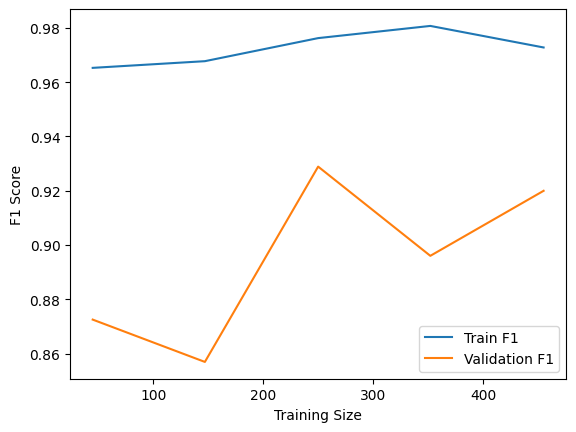

In [22]:
train_size, train_score, val_score= learning_curve(estimator= dt_grid_search, X= x, y= y, cv= 5, scoring= "f1", train_sizes= np.linspace(0.1,1.0, 5), shuffle= True, random_state= 7)

train_mean= train_score.mean(axis= 1)
val_mean= val_score.mean(axis= 1)

plt.plot(train_size, train_mean, label= "Train F1")
plt.plot(train_size, val_mean, label= "Validation F1")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

From the plot above, we can see that F1 score for the train set is around 0.96-0.98, meaning the model performs well on the training. However, the F1 score for the validation set fluctuates as the training size increases. The gap between train and validation F1 scores indicates moderate overfitting and high variance. This model behaviour is expected because Decision Trees are sensitive to small variations in data.

# Random Forest Classifier

In [23]:
rf_pipe= Pipeline(steps= [("smote", SMOTE( random_state= 7)), ("rf", models["RandomForest"])])

rf_params= {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [5, 10, 15],
    "rf__min_samples_split": [2, 5, 8]
}

rf_grid_search= GridSearchCV(estimator= rf_pipe, param_grid= rf_params, cv= cv_strat, n_jobs= -1, scoring= "recall", refit= True)
rf_grid_search.fit(X_train, y_train)
rf_grid_search.best_estimator_

,steps,"[('smote', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,7
,k_neighbors,5
,n_estimators,100
,criterion,'entropy'
,max_depth,5
,min_samples_split,2


In [24]:
preds= rf_grid_search.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95        72
           1       0.95      0.86      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



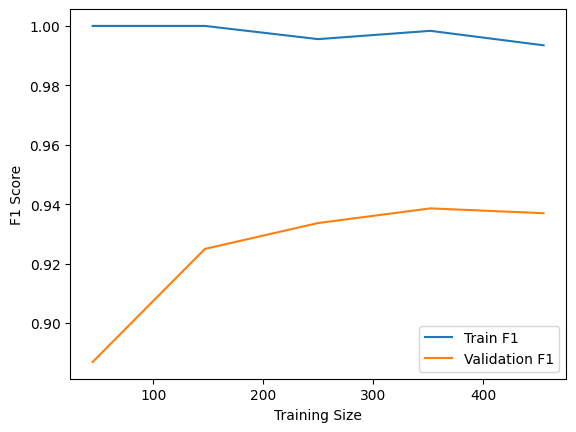

In [25]:
train_size, train_score, val_score= learning_curve(estimator= rf_grid_search, X= x, y= y, cv= 5, scoring= "f1", train_sizes= np.linspace(0.1,1.0, 5), shuffle= True, random_state= 7)

train_mean= train_score.mean(axis= 1)
val_mean= val_score.mean(axis= 1)

plt.plot(train_size, train_mean, label= "Train F1")
plt.plot(train_size, val_mean, label= "Validation F1")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

From the learning curve above, we can observe that the model performs well on the training set with an F1 score of around 0.98-1. However, the F1 score for validation set starts from around 0.89 and increases to 0.93 with increase in training size. The gap between train and validation suggests that the model is mildly overfitting, but vairance is not as high as in Decision Tree. The model plateaus at around 0.94, indicating that adding more data may not significantly improve the performance.

# XGBoost Classifier

In [26]:
xgb_pipe= Pipeline(steps= [("smote", SMOTE( random_state= 7)), ("xgb", models["XGBoost"])])

xgb_params= {
    "xgb__n_estimators": randint(50, 500),
    "xgb__max_depth": randint(5, 9),
    "xgb__learning_rate": uniform(0.01, 0.3),
    "xgb__subsample":  uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.6, 0.4),
    'xgb__gamma': uniform(0, 0.5),
}

random_search= RandomizedSearchCV(estimator= xgb_pipe, param_distributions= xgb_params, cv= cv_strat, scoring= "recall", refit= True, n_jobs= -1, n_iter= 50, random_state= 7)
random_search.fit(X_train, y_train)
random_search.best_estimator_

,steps,"[('smote', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,7
,k_neighbors,5
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [27]:
preds= random_search.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        72
           1       0.95      0.90      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



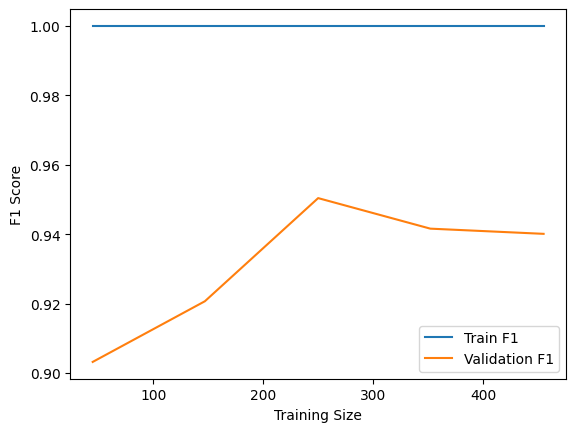

In [28]:
train_size, train_score, val_score= learning_curve(estimator= random_search, X= x, y= y, cv= 5, scoring= "f1", train_sizes= np.linspace(0.1,1.0, 5), shuffle= True, random_state= 7)

train_mean= train_score.mean(axis= 1)
val_mean= val_score.mean(axis= 1)

plt.plot(train_size, train_mean, label= "Train F1")
plt.plot(train_size, val_mean, label= "Validation F1")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

The plot above shows that the XGBoost model performs very well on the training set with an F1 score of 1. As for the performance on the validation set the F1 score starts at around 0.90 and rises to around 0.95 with the increase in training size. But with further increase in training size, the score stabilizes around 0.94-0.95, suggesting that the model has already reached its optimal performance on the given data, and is starting to overfit.